# 06 — The Backtest: From Signals to Dollars
## $1,000,000 · 10 bps Costs · 2022–2025 · Deploy, Iterate, or Abandon

**Jarvis Capital — Deep Learning Equity Signal Capstone**

Every model so far produced *predictions*. The desk trades *dollars*. This notebook runs each signal through one identical, deliberately simple portfolio rule and reports what the CIO, the Head of Risk, and the Technical Committee each need:

**The strategy (identical for every model):** each day, hold an equal-weight long position in every stock whose predicted next-day return is positive; hold cash for the rest. Long/flat only — no leverage, no shorting. **10 basis points** of transaction cost on every unit of turnover, so a signal that flips positions daily pays for it constantly.

**The benchmarks:**
- **SPY buy & hold** — what doing nothing clever earns.
- **Universe buy & hold** — equal-weight all 48 stocks, near-zero turnover: separates *stock-picking* from *signal timing*.
- **Linear (incumbent)** — the model the desk already runs.

Everything below is **net of costs** unless stated otherwise.

In [1]:
import sys, warnings, json
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data, plotting
from src.backtest import PortfolioBacktester, buy_and_hold
from src.plotting import (BLUE, ORANGE, AQUA, YELLOW, MAGENTA, MUTED, INK_2,
                          GRID, GOOD, CRITICAL, direct_label, fmt_pct,
                          fmt_dollars, year_axis, subtitle, save_figure,
                          plot_equity_with_drawdown, plot_monthly_heatmap)

plotting.apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

---
## 1. Assemble the Signals

Predictions were persisted per *(date, stock)* by notebooks 03 and 04 — nothing is recomputed here, so the backtest cannot accidentally peek at a model's training data.

In [2]:
tab = pd.read_parquet(config.PROCESSED_DIR / "predictions_tabular.parquet")
seq = pd.read_parquet(config.PROCESSED_DIR / "predictions_sequence.parquet")

merged = tab.merge(seq.drop(columns="actual"), on=["Date", "Ticker"], how="inner")
# cross-check: both files must agree on the realized returns
chk = tab.merge(seq[["Date", "Ticker", "actual"]], on=["Date", "Ticker"], suffixes=("", "_seq"))
assert np.allclose(chk["actual"], chk["actual_seq"]), "prediction files disagree on actuals!"
print(f"{len(merged):,} (date, stock) predictions   "
      f"{merged['Date'].min().date()} -> {merged['Date'].max().date()}")

SIGNALS = {"Linear (incumbent)": "pred_linear", "Feedforward NN": "pred_ffnn",
           "LSTM": "pred_lstm", "1D CNN": "pred_cnn1d"}
actual_w = merged.pivot(index="Date", columns="Ticker", values="actual")
print(f"universe in backtest: {actual_w.shape[1]} stocks, {len(actual_w)} trading days")

48,048 (date, stock) predictions   2022-01-03 -> 2025-12-29
universe in backtest: 48 stocks, 1001 trading days


In [3]:
# Benchmarks over the same dates
prices = data.load_prices()
spy_close = data.pivot_field(prices, "Close")["SPY"]
spy_ret = spy_close.pct_change().reindex(actual_w.index).dropna()
spy_equity, spy_stats = buy_and_hold(spy_ret)

# Universe buy & hold: equal-weight the 48 names, rebalanced daily (negligible turnover cost)
uni_ret = actual_w.mean(axis=1)
uni_equity, uni_stats = buy_and_hold(uni_ret)

vix = data.load_market()["vix"]

---
## 2. Run Every Signal Through the Same Engine

In [4]:
backtests, stats = {}, {}
for name, col in SIGNALS.items():
    pred_w = merged.pivot(index="Date", columns="Ticker", values=col)
    bt = PortfolioBacktester(pred_w, actual_w)
    backtests[name] = bt
    stats[name] = bt.stats()

stats["SPY buy & hold"] = spy_stats
stats["Universe buy & hold"] = uni_stats

table = pd.DataFrame(stats).T
order = ["annualized_return", "annualized_vol", "sharpe", "max_drawdown",
         "win_rate", "annual_turnover", "total_costs", "final_value", "dollar_pnl"]
table = table.reindex(columns=order)
table.columns = ["Ann. return", "Ann. vol", "Sharpe", "Max DD", "Win rate",
                 "Turnover/yr", "Costs ($)", "Final value ($)", "P&L ($)"]
table.round(3)

,Ann. return,Ann. vol,Sharpe,Max DD,Win rate,Turnover/yr,Costs ($),Final value ($),P&L ($)
Linear (incumbent),-0.077,0.199,-0.301,-0.412,0.517,159.263,"473,796.490","728,619.857","-271,380.143"
Feedforward NN,0.130,0.160,0.846,-0.213,0.540,4.271,"17,787.258","1,627,692.145","627,692.145"
LSTM,0.044,0.159,0.350,-0.205,0.529,42.768,"169,424.333","1,185,475.227","185,475.227"
1D CNN,-0.094,0.210,-0.367,-0.389,0.478,245.946,"701,224.402","675,442.860","-324,557.140"
SPY buy & hold,0.113,0.180,0.685,-0.245,NaN,NaN,NaN,"1,531,026.122","531,026.122"
Universe buy & hold,0.136,0.160,0.878,-0.209,NaN,NaN,NaN,"1,660,767.625","660,767.625"


**How to read this table.** The Sharpe column is the headline — the firm's target is **0.6** and the incumbent's trailing record is ~0.4. But Sharpe alone can hide fragility, which is why Max DD (the Head of Risk's column), Turnover/yr and Costs (the implementation reality), and the two buy-and-hold rows (the "do nothing" tests) sit beside it.

Best deep learning signal by net Sharpe: Feedforward NN  (Sharpe 0.85)


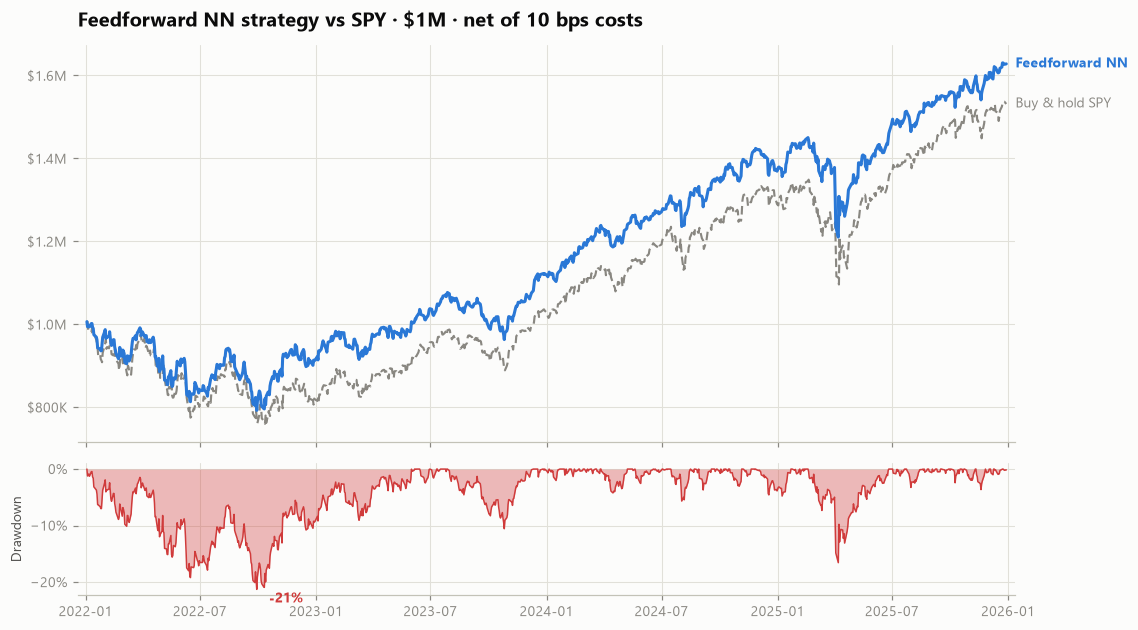

In [5]:
best_name = max(SIGNALS, key=lambda n: stats[n]["sharpe"])
best = backtests[best_name]
print(f"Best deep learning signal by net Sharpe: {best_name}  "
      f"(Sharpe {stats[best_name]['sharpe']:.2f})")

fig, _ = plot_equity_with_drawdown(
    best.equity, spy_equity,
    title=f"{best_name} strategy vs SPY \u00b7 $1M \u00b7 net of 10 bps costs",
    strategy_label=best_name)
save_figure(fig, "bt_equity_curve")
plt.show()

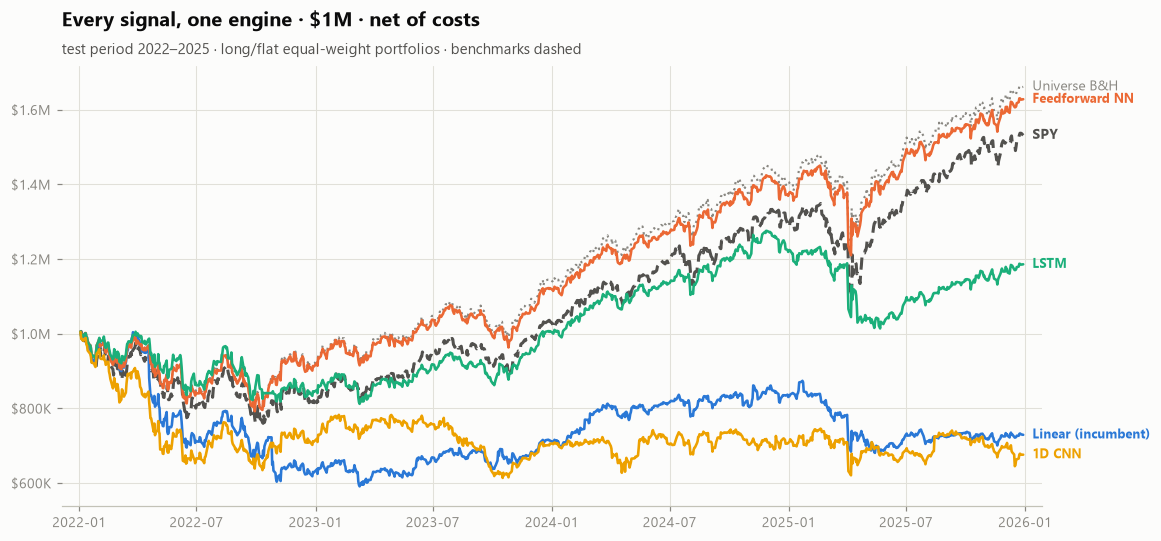

In [6]:
# All strategies on one panel - indexed to the same $1M start
fig, ax = plt.subplots(figsize=(11.5, 5.2))
palette = [BLUE, ORANGE, AQUA, YELLOW]
for (name, bt), c in zip(backtests.items(), palette):
    ax.plot(bt.equity.index, bt.equity.values, color=c, lw=1.7, zorder=3)
    direct_label(ax, bt.equity.index[-1], bt.equity.iloc[-1], name, c, fontsize=8.5)
ax.plot(spy_equity.index, spy_equity.values, color=INK_2, lw=2, ls=(0, (4, 2)), zorder=2)
direct_label(ax, spy_equity.index[-1], spy_equity.iloc[-1], "SPY", INK_2)
ax.plot(uni_equity.index, uni_equity.values, color=MUTED, lw=1.4, ls=(0, (1, 2)), zorder=2)
direct_label(ax, uni_equity.index[-1], uni_equity.iloc[-1], "Universe B&H", MUTED, weight="normal")
ax.set_title("Every signal, one engine \u00b7 $1M \u00b7 net of costs")
subtitle(ax, "test period 2022\u20132025 \u00b7 long/flat equal-weight portfolios \u00b7 benchmarks dashed")
fmt_dollars(ax)
ax.margins(x=0.02)
save_figure(fig, "bt_all_equity_curves")
plt.show()

---
## 3. Monthly Returns — the Texture of Performance

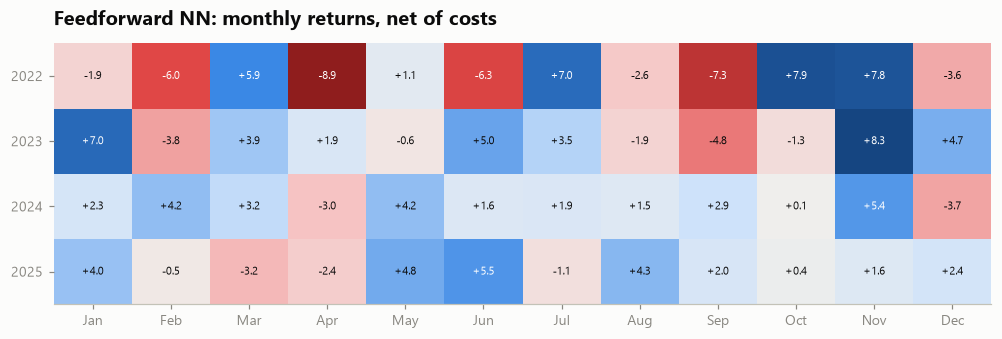

Best month:  Nov 2023  +8.3%
Worst month: Apr 2022  -8.9%
Months beating SPY: 26 of 48 (54%)


,Strategy,SPY,Excess
Date,,,
Jan 2025,+4.02%,+2.69%,+1.33%
Feb 2025,-0.45%,-1.27%,+0.82%
Mar 2025,-3.24%,-5.57%,+2.33%
Apr 2025,-2.36%,-0.87%,-1.50%
May 2025,+4.78%,+6.28%,-1.51%
Jun 2025,+5.49%,+5.14%,+0.36%
Jul 2025,-1.06%,+2.30%,-3.37%
Aug 2025,+4.35%,+2.05%,+2.29%
Sep 2025,+2.05%,+3.56%,-1.51%


In [7]:
monthly = best.monthly_returns()
spy_monthly = (1 + spy_ret).resample("ME").prod() - 1

fig, _ = plot_monthly_heatmap(monthly, title=f"{best_name}: monthly returns, net of costs")
save_figure(fig, "bt_monthly_heatmap")
plt.show()

mt = pd.DataFrame({"Strategy": monthly, "SPY": spy_monthly})
mt["Excess"] = mt["Strategy"] - mt["SPY"]
mt.index = mt.index.strftime("%b %Y")
print(f"Best month:  {mt['Strategy'].idxmax()}  {mt['Strategy'].max():+.1%}")
print(f"Worst month: {mt['Strategy'].idxmin()}  {mt['Strategy'].min():+.1%}")
print(f"Months beating SPY: {(mt['Excess'] > 0).sum()} of {len(mt)} ({(mt['Excess'] > 0).mean():.0%})")
mt.round(4).to_csv(config.REPORTS_DIR / "monthly_returns.csv")
mt.tail(12).style.format("{:+.2%}")

### Drawdown anatomy — the Head of Risk's exhibit

In [8]:
dd_events = best.drawdown_events(top_n=3)
dd_events["depth"] = dd_events["depth"].map("{:.1%}".format)
dd_events

,start,trough,end,depth,days
0,2022-01-04,2022-09-29,2023-06-06,-21.3%,357
1,2025-02-19,2025-04-07,2025-06-26,-16.6%,89
2,2023-07-31,2023-10-26,2023-12-11,-10.6%,94


---
## 4. Regime Analysis — When Does the Signal Work?

The EDA promised this slice: performance conditioned on the VIX regime prevailing each day. A signal that only works in calm markets needs a risk overlay before anyone deploys it.

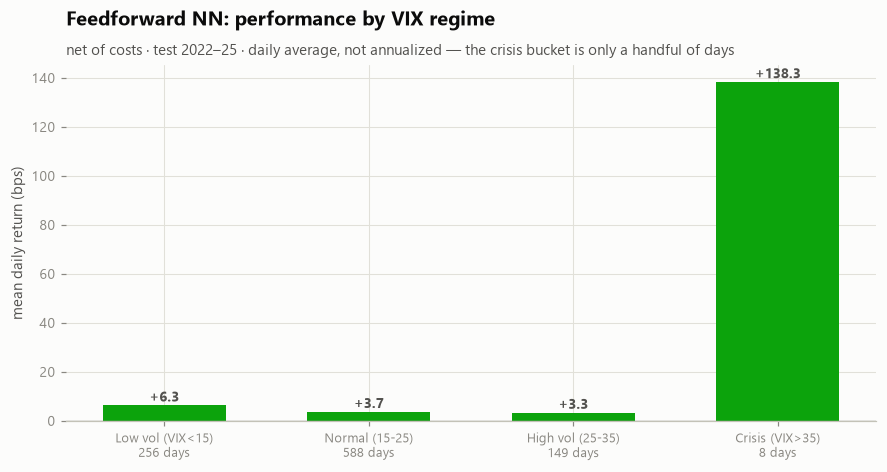

,days,mean_daily_bps,total_return,sharpe,pct_days_invested
regime,,,,,
Low vol (VIX<15),256,6.311,0.171,1.812,1.000
Normal (15-25),588,3.679,0.214,0.668,1.000
High vol (25-35),149,3.328,0.029,0.317,1.000
Crisis (VIX>35),8,138.331,0.113,7.898,1.000


In [9]:
regime = best.regime_table(vix)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
colors = [GOOD if v >= 0 else CRITICAL for v in regime["mean_daily_bps"]]
x = np.arange(len(regime))
ax.bar(x, regime["mean_daily_bps"], color=colors, width=0.6)
ax.axhline(0, color=MUTED, lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f"{i}\n{int(d)} days" for i, d in zip(regime.index, regime["days"])], fontsize=8.5)
for i, v in enumerate(regime["mean_daily_bps"]):
    ax.text(i, v + (0.4 if v >= 0 else -0.4), f"{v:+.1f}", ha="center",
            va="bottom" if v >= 0 else "top", fontsize=9, fontweight="bold", color=INK_2)
ax.set_ylabel("mean daily return (bps)")
ax.set_title(f"{best_name}: performance by VIX regime")
subtitle(ax, "net of costs \u00b7 test 2022\u201325 \u00b7 daily average, not annualized \u2014 the crisis bucket is only a handful of days")
save_figure(fig, "bt_regime_analysis")
plt.show()
regime.round(3)

---
## 5. Sensitivity: How Fragile Is the Result?

The single assumption with the most leverage is the **transaction cost**. Rerunning every backtest across 0–25 bps answers the Technical Committee's sharpest question: *does your conclusion survive realistic frictions?*

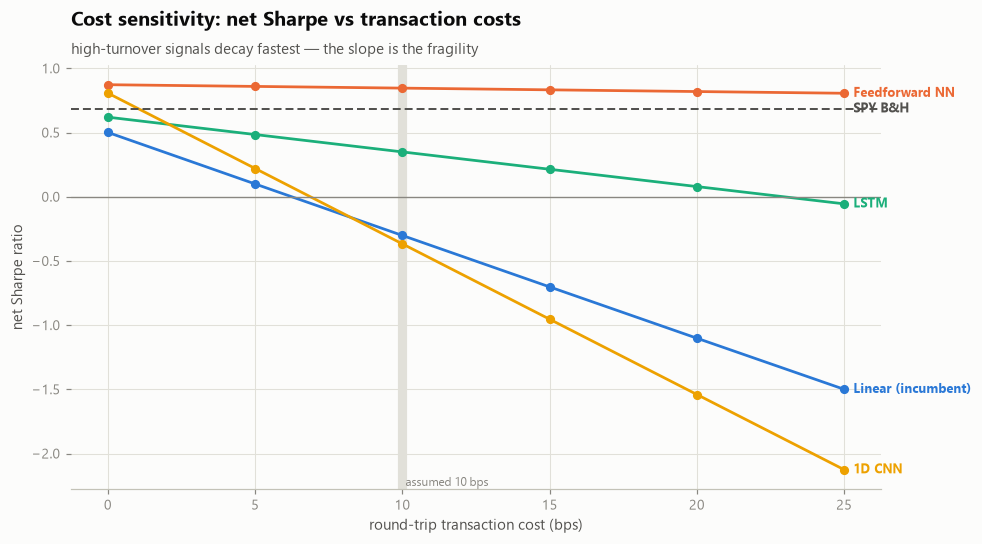

,Linear (incumbent),Feedforward NN,LSTM,1D CNN
0,0.501,0.873,0.620,0.807
5,0.100,0.860,0.485,0.220
10,-0.301,0.846,0.350,-0.367
15,-0.702,0.833,0.214,-0.954
20,-1.102,0.820,0.080,-1.540
25,-1.500,0.806,-0.055,-2.126


In [10]:
cost_grid = [0, 5, 10, 15, 20, 25]
sens = {}
for name, col in SIGNALS.items():
    pred_w = merged.pivot(index="Date", columns="Ticker", values=col)
    sens[name] = [PortfolioBacktester(pred_w, actual_w, cost_bps=c).stats()["sharpe"]
                  for c in cost_grid]
sens_df = pd.DataFrame(sens, index=cost_grid)

fig, ax = plt.subplots(figsize=(9.5, 5))
palette = [BLUE, ORANGE, AQUA, YELLOW]
for (name, vals), c in zip(sens_df.items(), palette):
    ax.plot(cost_grid, vals, color=c, lw=1.8, marker="o", markersize=5)
    direct_label(ax, cost_grid[-1], vals.iloc[-1], name, c, fontsize=8.5)
ax.axhline(spy_stats["sharpe"], color=INK_2, lw=1.3, ls=(0, (4, 2)))
direct_label(ax, cost_grid[-1], spy_stats["sharpe"], "SPY B&H", INK_2, fontsize=8.5)
ax.axhline(0, color=MUTED, lw=0.9)
ax.axvline(10, color=GRID, lw=6, zorder=0)
ax.text(10, ax.get_ylim()[0], " assumed 10 bps", fontsize=8, color=MUTED, va="bottom")
ax.set_xlabel("round-trip transaction cost (bps)")
ax.set_ylabel("net Sharpe ratio")
ax.set_title("Cost sensitivity: net Sharpe vs transaction costs")
subtitle(ax, "high-turnover signals decay fastest \u2014 the slope is the fragility")
save_figure(fig, "bt_cost_sensitivity")
plt.show()
sens_df.round(3)

---
## 6. Look-Ahead Bias Checklist — Verified, Not Asserted

| Check | Where it is enforced |
|---|---|
| ✅ Features use only trailing windows | `src/features.py` + truncation test in notebook 02 |
| ✅ Strictly temporal train/val/test splits | `src/config.py` boundaries, applied by date everywhere |
| ✅ Scaler fit on train only | Notebook 02, persisted and reused |
| ✅ Predictions made at close of *t* for return *t*→*t+1* | Target built with `shift(-1)`; sequence windows end at *t* |
| ✅ No overlap between training data and test windows | Warmup rows come from *earlier* periods only |
| ✅ Walk-forward validation, not a single split | Notebook 04, four expanding-window folds |
| ✅ Costs charged on every position change | `PortfolioBacktester` turnover accounting |

---
## 7. The Verdict — Three Tests

The recommendation follows mechanically from three questions, in order:

1. **Does the best deep learning signal beat the incumbent linear model, net of costs?** (Sharpe vs Sharpe, same engine, same period.)
2. **Does it beat doing nothing** — SPY and the equal-weight universe? A signal that trails buy-and-hold has negative value regardless of its cleverness.
3. **Does the conclusion survive the sensitivity grid** — and does the walk-forward spread from notebook 04 say the edge is stable across regimes?

In [11]:
verdict = pd.DataFrame({
    "Sharpe (net, 10 bps)": {
        best_name: stats[best_name]["sharpe"],
        "Linear (incumbent)": stats["Linear (incumbent)"]["sharpe"],
        "SPY buy & hold": spy_stats["sharpe"],
        "Universe buy & hold": uni_stats["sharpe"],
    },
    "Max drawdown": {
        best_name: stats[best_name]["max_drawdown"],
        "Linear (incumbent)": stats["Linear (incumbent)"]["max_drawdown"],
        "SPY buy & hold": spy_stats["max_drawdown"],
        "Universe buy & hold": uni_stats["max_drawdown"],
    },
    "Dollar P&L": {
        best_name: stats[best_name]["dollar_pnl"],
        "Linear (incumbent)": stats["Linear (incumbent)"]["dollar_pnl"],
        "SPY buy & hold": spy_stats["dollar_pnl"],
        "Universe buy & hold": uni_stats["dollar_pnl"],
    },
})
test1 = stats[best_name]["sharpe"] > stats["Linear (incumbent)"]["sharpe"]
test2 = stats[best_name]["sharpe"] > max(spy_stats["sharpe"], uni_stats["sharpe"])
test3 = sens_df[best_name].loc[20] > 0
print(f"Test 1 - beats incumbent linear:      {'PASS' if test1 else 'FAIL'}")
print(f"Test 2 - beats buy-and-hold:          {'PASS' if test2 else 'FAIL'}")
print(f"Test 3 - Sharpe > 0 at 20 bps costs:  {'PASS' if test3 else 'FAIL'}")

with open(config.PROCESSED_DIR / "results_06.json", "w") as f:
    json.dump({"stats": {k: v for k, v in stats.items()},
               "best_model": best_name,
               "tests": {"beats_incumbent": bool(test1),
                          "beats_buy_and_hold": bool(test2),
                          "survives_20bps": bool(test3)},
               "cost_sensitivity": sens_df.to_dict()}, f, indent=2, default=str)
verdict.round(3)

Test 1 - beats incumbent linear:      PASS
Test 2 - beats buy-and-hold:          FAIL
Test 3 - Sharpe > 0 at 20 bps costs:  PASS


,"Sharpe (net, 10 bps)",Max drawdown,Dollar P&L
Feedforward NN,0.846,-0.213,"627,692.145"
Linear (incumbent),-0.301,-0.412,"-271,380.143"
SPY buy & hold,0.685,-0.245,"531,026.122"
Universe buy & hold,0.878,-0.209,"660,767.625"


### Recommendation

The three tests above, plus the walk-forward stability evidence from notebook 04, determine the call — **deploy** (all three pass with a stable walk-forward), **iterate** (the signal beats the incumbent but fails a robustness test), or **abandon** (the signal adds nothing over the incumbent or buy-and-hold). The written verdict, with the full business justification and dollar quantification, is in [`reports/executive_summary.md`](../reports/executive_summary.md) and [`reports/backtest_report.md`](../reports/backtest_report.md) — built directly from the numbers this notebook just printed.